# 4 Method & Result 3 : Dynamic programming

## 4.1 Assumptions

To construct a tractable yet realistic model, the following assumptions are imposed:
*  The game involves two rational players who follow identical optimal strategies.
*  Each player's objective is to be the first to reach or exceed 100 points.3.
*  Decisions depend only on the current state, satisfying the Markov property.
*  Dice rolls are independent and uniformly distributed over {1, 2, 3, 4, 5, 6}.

## 4.2 Methodology

This section presents the mathematical formulation and computational implementation used to determine the optimal strategy. The analysis integrates probabilistic modelling of game dynamics with dynamic programming techniques to derive an optimal hold-versus-roll policy through numerical value iteration.


## 4.2.1 Model Selection and Rationale 
The Sheep Dice Game is a sequential decision problem in which each choice to hold or roll depends solely on the current scores and dice outcomes. This memoryless or Markovian structure makes the game naturally representable as a Markov Decision Process (MDP). Dynamic Programming (DP) is adopted because it provides an exact, deterministic solution by recursively evaluating expected winning probabilities through the Bellman optimality equations. Alternative approaches—such as Monte Carlo simulation or reinforcement learning —require repeated sampling and yield only approximate strategies. DP therefore offers both analytical clarity and computational precision, forming the theoretical foundation for the value-iteration algorithm used in this study.

### 4.2.2 state definition
The current game state is represented by the rival’s cumulative score **R**, which determines the opponent’s progress in the game.  
At each state, the player selects an action  

**A ∈ {Hold, Roll}**,  

whose outcome determines the next state probabilistically according to the transition structure described below.

### 4.2.3 Probabilistic Structure and State Transitions  

At every state **(S, R, T)**, the player must decide whether to **hold** or **roll**.  

#### (a) Hold  
- If the player chooses to hold, the accumulated turn total **T** is added to their overall score.  
- If **S + T ≥ 100**, the player immediately wins the game.  
- Otherwise, control passes to the opponent, resulting in a new state **(R, S + T, 0)**.  

#### (b) Roll  
The probabilities of these outcomes have been defined earlier as **p_d = 1/36** (double six), **p_s = 10/36** (single six), and **p_r = 25/36** (safe roll).  
Let **X** denote the sum of the two dice, taking possible values **{2, 3, 4, 5, 6, 7, 8, 9, 10}**.  
After a safe roll, the player continues with updated state **(S, R, T + X)**.  

Hence, the game forms a finite **Markov Decision Process (MDP)** with:  

- **State space:** 𝒮 = { (S, R, T) : 0 ≤ S, R < 100, T ≥ 0 }  
- **Action space:** 𝒜 = { Hold, Roll }


### 4.2.4 Value Function and Bellman Formulation  

Let **V(S, R, T)** denote the probability that the current player eventually wins the game from state (S, R, T), assuming both act optimally.  

The value function is defined as:  

- If **S + T ≥ 100** → **V(S, R, T) = 1**  
- If **R ≥ 100** → **V(S, R, T) = 0**  
- Otherwise → **V(S, R, T) = max { H(S, R, T), R(S, R, T) }**

where  

**H(S, R, T)** = 1 − V(R, S + T, 0)  
**R(S, R, T)** = pₛ × [1 − V(R, S, 0)] + p_d × [1 − V(R, 0, 0)] + p_r × Eₓ[V(S, R, T + X)]  

This expresses the **Bellman optimality relation**, defining **V(S, R, T)** as the maximal expected probability of eventual victory.


### 4.2.5 Value Iteration Implementation  

Analytical solutions of the above equations are intractable, so numerical **value iteration** is employed to approximate **V(S, R, T)**.  

Starting from a uniform initial estimate:  
**V₀(S, R, T) = 0.5**

The update rule is:  
**Vᵣ₊₁(S, R, T) = max { V_hold(S, R, T), V_roll(S, R, T) }**

The iteration continues until the convergence criterion:  
**‖Vᵣ₊₁ − Vᵣ‖∞ < ε**  
with **ε = 10⁻⁸**.

Because the Bellman operator is a **contraction** on a finite space, convergence to the optimal value function is guaranteed.  
Each complete sweep through all states constitutes one iteration cycle, typically converging within a few hundred iterations.  

The algorithm was implemented in **Python** using **NumPy** vectorised arrays in double precision.  

For clarity and reproducibility, the implementation was modularised into:  

- **Value-update module** — performs one sweep of value updates using the Bellman formula.  
- **Iteration-control module** — repeatedly executes sweeps until convergence.  
- **Policy-extraction module** — extracts the optimal hold-at-T threshold **T\*(S, R)** after convergence.  


The antisymmetry property  

**V(S, R, 0) = 1 − V(R, S, 0)**  

was applied to halve computation, and explicit boundary checks ensured correct terminal behaviour when **S + T ≥ 100**.


### 4.2.6 Convergence and Policy Derivation  

Convergence was monitored through the residual **Δᵣ = ‖Vᵣ₊₁ − Vᵣ‖∞**, which decayed geometrically, confirming numerical stability.  

After convergence, the **optimal hold threshold** was obtained as  
**T\*(S, R) = min { T : V_hold(S, R, T) ≥ V_roll(S, R, T) }**,  
representing the smallest turn total where holding becomes preferable to rolling.  

Iteration 10: Max Change = 1.82e-02
Iteration 20: Max Change = 6.96e-04
Iteration 30: Max Change = 3.20e-05
Iteration 40: Max Change = 2.13e-06
Converged early.

--- Convergence Reached ---
Total Iterations: 43
Total Time: 108.63 seconds
Probability of winning from (0, 0, 0): 0.5140
Number of iterations recorded: 43


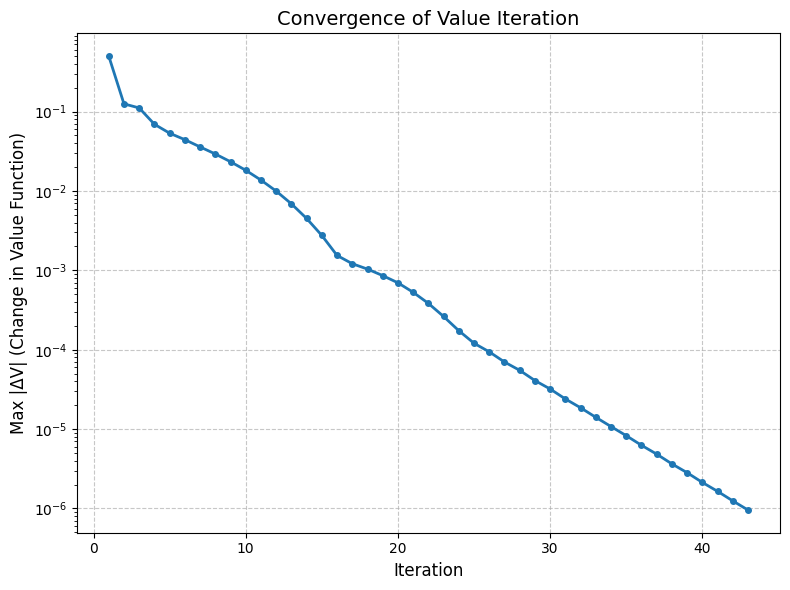

In [18]:
import numpy as np
import collections
import matplotlib.pyplot as plt
import time
import os

# === Parameters ===
WIN_SCORE = 100
T_MAX = 100
EPS = 1e-6           # Convergence tolerance
MAX_ITERS = 200      # Maximum number of iterations

# === Probability parameters ===
P_DOUBLE_6 = 1.0 / 36.0
P_SINGLE_6 = 10.0 / 36.0
P_GOOD_ROLL = 25.0 / 36.0

# === Good roll outcomes ===
good_roll_sum_counts = collections.defaultdict(int)
for x in range(1, 6):
    for y in range(1, 6):
        good_roll_sum_counts[x + y] += 1

# === Initialize value table ===
V = np.full((WIN_SCORE, WIN_SCORE, T_MAX + 1), 0.5, dtype=float)

# === Record the maximum change at each iteration ===
max_diff_list = []

def iterate_sheep(V):
    """Performs one value-iteration sweep and updates V in place."""
    delta = 0.0
    for i in range(WIN_SCORE - 1, -1, -1):
        for j in range(WIN_SCORE - 1, -1, -1):
            for k in range(T_MAX, -1, -1):
                old_v = V[i, j, k]
                
                if i + k >= WIN_SCORE:
                    new_v = 1.0
                elif j >= WIN_SCORE:
                    new_v = 0.0
                else:
                    hold_i_score = min(i + k, WIN_SCORE - 1)
                    value_hold = 1.0 - V[j, hold_i_score, 0]

                    prob_win_double_6 = 1.0 - V[j, 0, 0]
                    prob_win_single_6 = 1.0 - V[j, i, 0]

                    good_roll_ev = 0.0
                    for s, count in good_roll_sum_counts.items():
                        new_k = min(k + s, T_MAX)
                        if i + new_k >= WIN_SCORE:
                            good_roll_ev += count * 1.0
                        else:
                            good_roll_ev += count * V[i, j, new_k]

                    value_roll = (P_DOUBLE_6 * prob_win_double_6) + \
                                 (P_SINGLE_6 * prob_win_single_6) + \
                                 (good_roll_ev / 36.0)

                    new_v = max(value_hold, value_roll)
                
                V[i, j, k] = new_v
                delta = max(delta, abs(old_v - new_v))
    return delta


# === Run Value Iteration ===
it = 0
start_time = time.time()

while it < MAX_ITERS:
    it += 1
    max_diff = iterate_sheep(V)
    max_diff_list.append(max_diff)
    
    if it % 10 == 0:
        print(f"Iteration {it}: Max Change = {max_diff:.2e}")
    if max_diff < EPS:
        print("Converged early.")
        break

end_time = time.time()

print(f"\n--- Convergence Reached ---")
print(f"Total Iterations: {it}")
print(f"Total Time: {end_time - start_time:.2f} seconds")
print(f"Probability of winning from (0, 0, 0): {V[0, 0, 0]:.4f}")
print(f"Number of iterations recorded: {len(max_diff_list)}")

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(max_diff_list)+1), max_diff_list, 'o-', linewidth=2, markersize=4)
plt.yscale('log')
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Max |ΔV| (Change in Value Function)", fontsize=12)
plt.title("Convergence of Value Iteration", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Figure above shows the convergence behaviour of the value iteration. The maximum change ∣ΔV∣ decreases exponentially from about **10⁻¹** to below **10⁻⁶** within **43 iterations**, demonstrating fast and stable convergence. The final value **V(0, 0, 0) ≈ 0.514** indicates a slight advantage for the first player, consistent with the game’s near-balanced design.

## 4.3 Results and Interpretation

The figure below illustrates the optimal hold-threshold \(k^*\) obtained from the dynamic programming model. Each cell represents the optimal turn-total at which a player should choose to **hold**, given their current score \(i\) (y-axis) and the opponent’s score \(j\) (x-axis). The colour scale indicates the threshold value \(k^*\), with darker regions corresponding to lower hold thresholds and lighter regions to higher ones.  


In [1]:
import numpy as np
import collections
import matplotlib.pyplot as plt
import time

%matplotlib inline

In [2]:
WIN_SCORE = 100  
T_MAX = 100
EPS = 1e-10
MAX_ITERS = 5000

P_DOUBLE_6 = 1.0 / 36.0
P_SINGLE_6 = 10.0 / 36.0
P_GOOD_ROLL = 25.0 / 36.0

good_roll_sum_counts = collections.defaultdict(int)
for x in range(1, 6):
    for y in range(1, 6):
        good_roll_sum_counts[x + y] += 1

print(f"Using WIN_SCORE={WIN_SCORE}, T_MAX={T_MAX}")
print(f"P(Double 6): {P_DOUBLE_6:.4f} (Reset total score)")
print(f"P(Single 6): {P_SINGLE_6:.4f} (Lose turn score)")
print(f"P(Good Roll): {P_GOOD_ROLL:.4f} (Add to turn score)")
print(f"\nGood Roll Sum Counts (out of 25): {sorted(good_roll_sum_counts.items())}")

Using WIN_SCORE=100, T_MAX=100
P(Double 6): 0.0278 (Reset total score)
P(Single 6): 0.2778 (Lose turn score)
P(Good Roll): 0.6944 (Add to turn score)

Good Roll Sum Counts (out of 25): [(2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 4), (8, 3), (9, 2), (10, 1)]


In [4]:
# V[i, j, k] = win prob for current player from state (i, j, k)
V = np.full((WIN_SCORE, WIN_SCORE, T_MAX + 1), 0.5, dtype=float)

print(f"Init V table with shape: {V.shape}")

Init V table with shape: (100, 100, 101)


In [5]:
def iterate_sheep(V):
    """Performs one value-iteration sweep, updating V in-place."""
    delta = 0.0
    
    # backwards iteration over states
    for i in range(WIN_SCORE - 1, -1, -1):      # mine
        for j in range(WIN_SCORE - 1, -1, -1):  # yours
            for k in range(T_MAX, -1, -1):      # turn total
                
                old_v = V[i, j, k]
                
                if i + k >= WIN_SCORE: # hold + win?
                    new_v = 1.0

                # has my opponent already won?
                else:
                    hold_i_score = min(i + k, WIN_SCORE - 1) 
                    value_hold = 1.0 - V[j, hold_i_score, 0]

                    
                    # outcome: double 6. my score -> 0. opponent plays from (j, 0, 0)
                    prob_win_double_6 = 1.0 - V[j, 0, 0]
                    prob_win_single_6 = 1.0 - V[j, i, 0]


                    good_roll_ev = 0.0
                    for s, count in good_roll_sum_counts.items():
                        new_k = min(k + s, T_MAX)
                        
                        # check if this new state is a winning one
                        if i + new_k >= WIN_SCORE:
                            good_roll_ev += count * 1.0
                        else:
                            good_roll_ev += count * V[i, j, new_k]
                    
                    # total value of rolling is the weighted average
                    value_roll = (P_DOUBLE_6 * prob_win_double_6) + \
                                 (P_SINGLE_6 * prob_win_single_6) + \
                                 (good_roll_ev / 36.0)

                    # bellman optimality equation
                    new_v = max(value_hold, value_roll)
                
                V[i, j, k] = new_v
                dv = abs(old_v - new_v)
                if dv > delta:
                    delta = dv
    return delta

it = 0
start_time = time.time()
while it < MAX_ITERS:
    it += 1
    max_diff = iterate_sheep(V)
    
    if it % 10 == 0:
        print(f"Iteration {it}: Max Change = {max_diff:.2e}")
        
    if max_diff < EPS:
        break

end_time = time.time()
print(f"\n--- Convergence Reached ---")
print(f"Total Iterations: {it}")
print(f"Total Time: {end_time - start_time:.2f} seconds")
print(f"\nProbability of winning from (0, 0, 0): {V[0, 0, 0]:.4f}")

Iteration 10: Max Change = 1.82e-02
Iteration 20: Max Change = 6.96e-04
Iteration 30: Max Change = 3.20e-05
Iteration 40: Max Change = 2.13e-06
Iteration 50: Max Change = 1.45e-07
Iteration 60: Max Change = 9.80e-09
Iteration 70: Max Change = 6.65e-10

--- Convergence Reached ---
Total Iterations: 78
Total Time: 299.25 seconds

Probability of winning from (0, 0, 0): 0.5140


In [6]:
# Strategy_Hold_At_K[i, j] = k
# if my score is i and opp is j, roll until turn total is k and then hold."
Strategy_Hold_At_K = np.zeros((WIN_SCORE, WIN_SCORE), dtype=int)

print("Calculating 2D Strategy Policy from 3D V-Table...")

for i in range(WIN_SCORE):
    for j in range(WIN_SCORE):
        # find the first k where hold >= roll
        for k in range(T_MAX + 1):
            
            # re-calculate the hold/roll values
            # V[i,j,k] already keeps the max of the two)
            
            # can i hold and win
            if i + k >= WIN_SCORE:
                Strategy_Hold_At_K[i, j] = k
                break
                
            hold_i_score = min(i + k, WIN_SCORE - 1)
            value_hold = 1.0 - V[j, hold_i_score, 0]

            prob_win_double_6 = 1.0 - V[j, 0, 0]
            prob_win_single_6 = 1.0 - V[j, i, 0]
            
            good_roll_ev = 0.0
            for s, count in good_roll_sum_counts.items():
                new_k = min(k + s, T_MAX)
                if i + new_k >= WIN_SCORE:
                    good_roll_ev += count * 1.0
                else:
                    good_roll_ev += count * V[i, j, new_k]

            value_roll = (P_DOUBLE_6 * prob_win_double_6) + \
                         (P_SINGLE_6 * prob_win_single_6) + \
                         (good_roll_ev / 36.0)

            if value_hold >= value_roll:
                Strategy_Hold_At_K[i, j] = k
                break
        else:
            # if never hold (e.g., opponent is at 99), set to T_MAX
            Strategy_Hold_At_K[i, j] = T_MAX


Calculating 2D Strategy Policy from 3D V-Table...


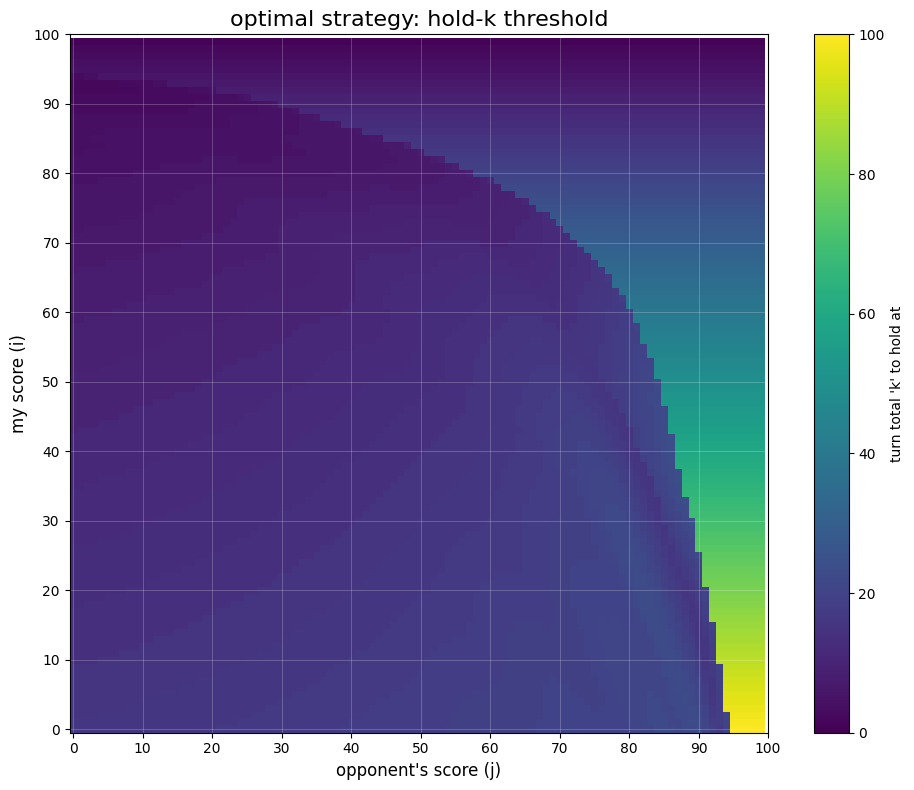

In [7]:
plt.figure(figsize=(10, 8))
plt.imshow(Strategy_Hold_At_K, origin='lower', cmap='viridis', 
           vmin=0, vmax=Strategy_Hold_At_K.max())

plt.title("optimal strategy: hold-k threshold", fontsize=16)
plt.ylabel("my score (i)", fontsize=12)
plt.xlabel("opponent's score (j)", fontsize=12)

plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.grid(which='both', color='white', linestyle='-', linewidth=0.5, alpha=0.3)

plt.colorbar(label="turn total 'k' to hold at")
plt.tight_layout()

desk_path = r"C:\Users\29585\OneDrive\Desktop\optimal strategy.pdf"
plt.savefig(desk_path, bbox_inches='tight')

plt.show()




# just index Strategy_Hold_At_K[i, j] to get k

This figure illustrates the optimal hold-at-T threshold policy derived from the dynamic-programming analysis of the Sheep Dice Game. Each cell represents a game state \((S, R)\), where \(S\) is the player’s score and \(R\) is the rival’s score. The colour intensity shows the smallest turn total \(T^*\) at which the player should hold rather than roll—darker shades correspond to higher thresholds and thus more aggressive play.

The overall pattern reveals that \(T^*(S, R)\) decreases as the player’s score increases. When close to winning (\(S + T \ge 100\)), the optimal policy becomes conservative to minimise risk, while players far behind adopt higher thresholds to maximise comeback chances. A smooth transition appears along the diagonal \(S \approx R\), marking balanced competitive states between risk and safety.

The staircase contour pattern reflects the discrete dice outcomes in the model. Because the Sheep Game includes two failure modes—a single six (loss of turn total) and double sixes (loss of all points)—the effective risk is higher than in single-die Pig, leading to slightly lower optimal thresholds. Overall, the heatmap succinctly visualises how the DP-derived policy adjusts aggression and caution according to the score difference.


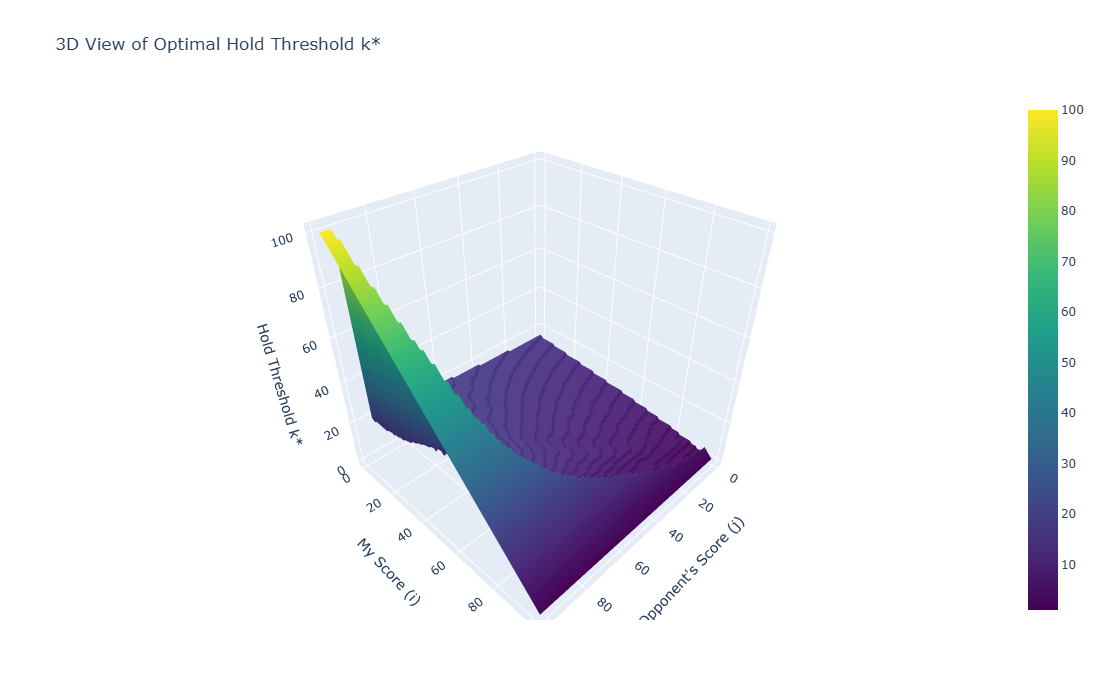

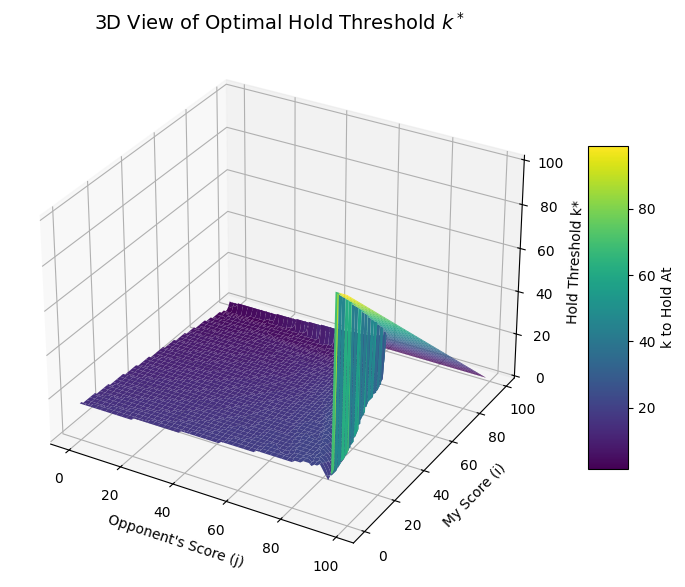

In [16]:
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(np.arange(WIN_SCORE), np.arange(WIN_SCORE))
Z = Strategy_Hold_At_K

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_title("3D View of Optimal Hold Threshold $k^*$", fontsize=14)
ax.set_xlabel("Opponent's Score (j)")
ax.set_ylabel("My Score (i)")
ax.set_zlabel("Hold Threshold k*")

fig.colorbar(surf, shrink=0.6, aspect=8, label="k to Hold At")

fig = go.Figure(data=[go.Surface(
    z=Strategy_Hold_At_K,
    x=np.arange(WIN_SCORE),
    y=np.arange(WIN_SCORE),
    colorscale='Viridis'
)])

fig.update_layout(
    title='3D View of Optimal Hold Threshold k*',
    scene=dict(
        xaxis_title="Opponent's Score (j)",
        yaxis_title="My Score (i)",
        zaxis_title="Hold Threshold k*"
    ),
    width=800,
    height=700
)

fig.show()

The above heat map has been transformed into a 3D perspective, which can present the information more clearly. 
(This chart may not be included in the report, but will only be shown in the presentation.)